In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix



In [3]:
data = pd.read_csv("student_performance.csv")
data


,StudyHours,Attendance,InternalMarks,Result
0,1,45,25,Fail
1,2,50,30,Fail
2,2,55,35,Fail
3,3,60,40,Fail
4,3,62,42,Fail
5,4,65,45,Fail
6,4,68,48,Fail
7,5,70,50,Pass
8,5,72,52,Pass
9,5,75,55,Pass


In [4]:
data.info()




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33 entries, 0 to 32
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   StudyHours     33 non-null     int64 
 1   Attendance     33 non-null     int64 
 2   InternalMarks  33 non-null     int64 
 3   Result         33 non-null     object
dtypes: int64(3), object(1)
memory usage: 1.2+ KB


In [5]:
data.describe()


,StudyHours,Attendance,InternalMarks
count,33.000000,33.000000,33.000000
mean,5.727273,74.969697,58.454545
std,2.660742,15.191455,18.843253
min,1.000000,45.000000,25.000000
25%,4.000000,65.000000,45.000000
50%,6.000000,76.000000,58.000000
75%,8.000000,88.000000,74.000000
max,10.000000,97.000000,90.000000


In [6]:
data['Result'].value_counts()


,count
Result,
Pass,21
Fail,12


In [7]:
X = data[['StudyHours', 'Attendance', 'InternalMarks']]
y = data['Result']

X, y


(    StudyHours  Attendance  InternalMarks
 0            1          45             25
 1            2          50             30
 2            2          55             35
 3            3          60             40
 4            3          62             42
 5            4          65             45
 6            4          68             48
 7            5          70             50
 8            5          72             52
 9            5          75             55
 10           6          76             58
 11           6          78             60
 12           6          80             62
 13           7          82             65
 14           7          85             68
 15           7          88             70
 16           8          85             72
 17           8          88             75
 18           8          90             78
 19           9          90             80
 20           9          92             82
 21           9          95             85
 22        

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)


Training samples: (23, 3)
Testing samples: (10, 3)


In [9]:
model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=4,
    random_state=42
)

model.fit(X_train, y_train)


DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)

In [10]:
y_pred = model.predict(X_test)

y_pred


array(['Pass', 'Pass', 'Fail', 'Pass', 'Pass', 'Pass', 'Pass', 'Pass',
       'Pass', 'Fail'], dtype=object)

In [11]:
accuracy = accuracy_score(y_test, y_pred)
accuracy


1.0

In [12]:
confusion_matrix(y_test, y_pred)


array([[2, 0],
       [0, 8]])

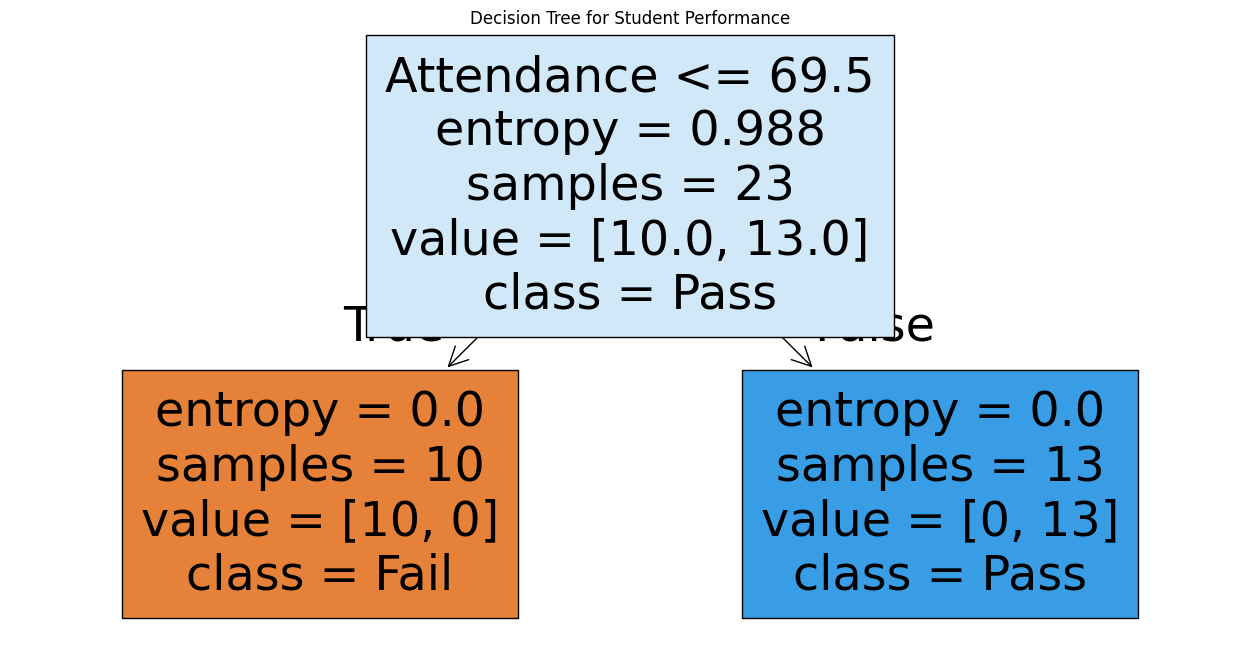

In [13]:
plt.figure(figsize=(16, 8))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=['Fail', 'Pass'],
    filled=True
)
plt.title("Decision Tree for Student Performance")
plt.show()


In [14]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison


,Actual,Predicted
0,Pass,Pass
1,Pass,Pass
2,Fail,Fail
3,Pass,Pass
4,Pass,Pass
5,Pass,Pass
6,Pass,Pass
7,Pass,Pass
8,Pass,Pass
9,Fail,Fail


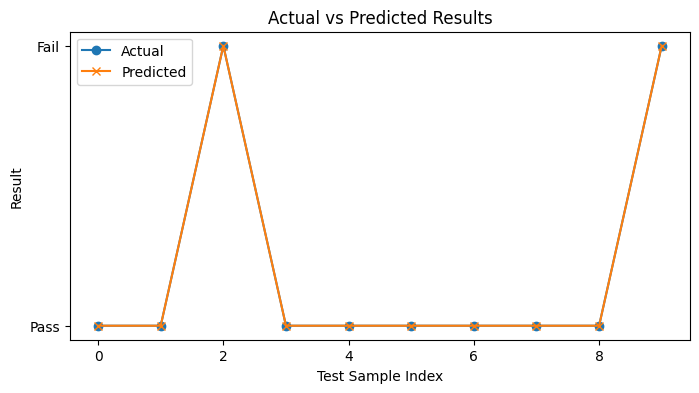

In [15]:
plt.figure(figsize=(8,4))
plt.plot(comparison['Actual'], label="Actual", marker='o')
plt.plot(comparison['Predicted'], label="Predicted", marker='x')
plt.title("Actual vs Predicted Results")
plt.xlabel("Test Sample Index")
plt.ylabel("Result")
plt.legend()
plt.show()


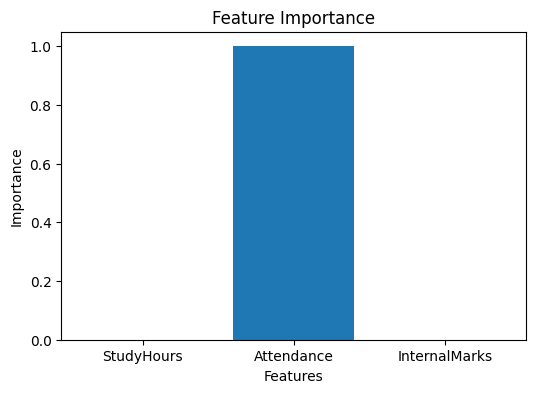

In [16]:
importances = model.feature_importances_
features = X.columns

plt.figure(figsize=(6,4))
plt.bar(features, importances)
plt.title("Feature Importance")
plt.ylabel("Importance")
plt.xlabel("Features")
plt.show()
